# data.xlsx veri analizi

Bu not defteri, `data.xlsx` içindeki iki sayfayı temizleyip zaman serisi, özet istatistikler ve meteorolojik etkiler açısından inceler.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

In [2]:
file_path = 'data.xlsx'
radio_sheet = '21.2GHz 2.8 km '
weather_sheet = 'Sheet2'

radio = pd.read_excel(file_path, sheet_name=radio_sheet)
radio.columns = radio.columns.str.strip()
radio['Collection Time'] = (
    radio['Collection Time']
    .astype(str)
    .str.replace(' UTC+03:00', '', regex=False)
)
radio['Collection Time'] = pd.to_datetime(radio['Collection Time'], dayfirst=True, errors='coerce')

radio_numeric_cols = ['RSL_MAX(dBm)', 'RSL_MIN(dBm)', 'TSL_MAX(dBm)', 'TSL_MIN(dBm)']
for column in radio_numeric_cols:
    radio[column] = pd.to_numeric(radio[column], errors='coerce')

radio['RSL_range(dB)'] = radio['RSL_MAX(dBm)'] - radio['RSL_MIN(dBm)']

weather_raw = (
    pd.read_excel(file_path, sheet_name=weather_sheet, header=None)
    .dropna(how='all')
    .reset_index(drop=True)
)
weather = weather_raw.iloc[1:].copy()
weather.columns = weather_raw.iloc[0].astype(str).str.strip()
weather = weather.rename(columns={'TEMP (ｰC)': 'TEMP (C)', 'Refrence': 'Reference'})
weather['History file UTC Time'] = pd.to_datetime(weather['History file UTC Time'], errors='coerce')

weather_numeric_cols = [
    'MOR_1A',
    'TEMP (C)',
    'RH (%)',
    'PAINS (HPA)',
    '1H RAIN (MM)',
    'WSINS (KT)',
    'RSL',
    'Reference',
    'dB',
    'dB/km',
]
for column in weather_numeric_cols:
    weather[column] = pd.to_numeric(weather[column], errors='coerce')

weather['rain_event'] = weather['1H RAIN (MM)'].fillna(0).gt(0)
weather = weather.sort_values('History file UTC Time').reset_index(drop=True)
radio = radio.sort_values('Collection Time').reset_index(drop=True)

print(f'Radio sheet shape: {radio.shape}')
print(f'Weather sheet shape: {weather.shape}')

Radio sheet shape: (2607, 8)
Weather sheet shape: (39074, 12)


In [3]:
overview = pd.DataFrame(
    {
        'dataset': ['radio', 'weather'],
        'rows': [len(radio), len(weather)],
        'columns': [radio.shape[1], weather.shape[1]],
        'start': [radio['Collection Time'].min(), weather['History file UTC Time'].min()],
        'end': [radio['Collection Time'].max(), weather['History file UTC Time'].max()],
    }
)

missing_summary = pd.concat(
    {
        'radio_missing': radio.isna().sum(),
        'weather_missing': weather.isna().sum(),
    },
    axis=1,
)

print('Genel veri özeti')
display(overview)

print('Eksik değer özeti')
display(missing_summary[missing_summary.sum(axis=1) > 0].sort_values(by=list(missing_summary.columns), ascending=False))

print('Radio örnek kayıtları')
display(radio.head())

print('Weather örnek kayıtları')
display(weather.head())

Genel veri özeti


,dataset,rows,columns,start,end
0,radio,2607,8,2014-06-02 00:00:00,2014-07-02 10:15:00
1,weather,39074,12,2014-06-01 21:00:00,2014-07-02 07:29:00


Eksik değer özeti


,radio_missing,weather_missing
Collection Time,2.00,NaN
RSL_MAX(dBm),2.00,NaN
RSL_MIN(dBm),2.00,NaN
TSL_MAX(dBm),2.00,NaN
TSL_MIN(dBm),2.00,NaN
RSL_range(dB),2.00,NaN
Resource Name,1.00,NaN
Granularity,1.00,NaN
WSINS (KT),NaN,"17,646.00"
MOR_1A,NaN,26.00


Radio örnek kayıtları


,Resource Name,Collection Time,Granularity,RSL_MAX(dBm),RSL_MIN(dBm),TSL_MAX(dBm),TSL_MIN(dBm),RSL_range(dB)
0,KHB027 koukou-55-ODU-1(RTNRF-1),2014-06-02 00:00:00,15 Min(maygooma events),-44.30,-46.10,-55.00,-55.00,1.80
1,KHB027 koukou-55-ODU-1(RTNRF-1),2014-06-02 00:15:00,15 Min(maygooma events),-45.30,-45.90,-55.00,-55.00,0.60
2,KHB027 koukou-55-ODU-1(RTNRF-1),2014-06-02 00:30:00,15 Min(maygooma events),-45.40,-45.90,-55.00,-55.00,0.50
3,KHB027 koukou-55-ODU-1(RTNRF-1),2014-06-02 00:45:00,15 Min(maygooma events),-45.10,-45.80,-55.00,-55.00,0.70
4,KHB027 koukou-55-ODU-1(RTNRF-1),2014-06-02 01:00:00,15 Min(maygooma events),-45.20,-45.60,-55.00,-55.00,0.40


Weather örnek kayıtları


,History file UTC Time,MOR_1A,TEMP (C),RH (%),PAINS (HPA),1H RAIN (MM),WSINS (KT),RSL,Reference,dB,dB/km,rain_event
0,2014-06-01 21:00:00,"4,400.00",36.20,23.00,962.70,0.00,5.64,-46.10,-43.80,2.30,0.82,False
1,2014-06-01 21:01:00,"4,500.00",36.10,23.00,962.70,0.00,5.25,-46.10,-43.80,2.30,0.82,False
2,2014-06-01 21:02:00,"4,600.00",36.10,23.00,962.70,0.00,4.47,-46.10,-43.80,2.30,0.82,False
3,2014-06-01 21:03:00,"4,600.00",36.10,23.00,962.80,0.00,4.28,-46.10,-43.80,2.30,0.82,False
4,2014-06-01 21:04:00,"4,700.00",36.10,23.00,962.80,0.00,5.25,-46.10,-43.80,2.30,0.82,False


In [4]:
radio_summary = radio[radio_numeric_cols + ['RSL_range(dB)']].describe().T
weather_summary = weather[weather_numeric_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.95]).T

radio_highlights = pd.DataFrame(
    {
        'metric': ['RSL_MAX mean', 'RSL_MIN mean', 'TSL_MAX unique', 'Max RSL swing'],
        'value': [
            radio['RSL_MAX(dBm)'].mean(),
            radio['RSL_MIN(dBm)'].mean(),
            radio['TSL_MAX(dBm)'].nunique(),
            radio['RSL_range(dB)'].max(),
        ],
    }
)

weather_highlights = pd.DataFrame(
    {
        'metric': ['Mean attenuation', 'Max attenuation', 'Rain event ratio', 'Mean humidity'],
        'value': [
            weather['dB'].mean(),
            weather['dB'].max(),
            weather['rain_event'].mean(),
            weather['RH (%)'].mean(),
        ],
    }
)

print('Radio istatistikleri')
display(radio_summary)
display(radio_highlights)

print('Weather istatistikleri')
display(weather_summary)
display(weather_highlights)

Radio istatistikleri


,count,mean,std,min,25%,50%,75%,max
RSL_MAX(dBm),"2,605.00",-44.50,0.58,-45.70,-45.00,-44.50,-44.10,-42.30
RSL_MIN(dBm),"2,605.00",-45.65,0.54,-53.20,-46.00,-45.70,-45.40,-44.10
TSL_MAX(dBm),"2,605.00",-55.00,0.00,-55.00,-55.00,-55.00,-55.00,-55.00
TSL_MIN(dBm),"2,605.00",-55.00,0.00,-55.00,-55.00,-55.00,-55.00,-55.00
RSL_range(dB),"2,605.00",1.15,0.53,0.20,0.80,1.10,1.40,8.20


,metric,value
0,RSL_MAX mean,-44.50
1,RSL_MIN mean,-45.65
2,TSL_MAX unique,1.00
3,Max RSL swing,8.20


Weather istatistikleri


,count,mean,std,min,25%,50%,75%,95%,max
0,,,,,,,,,
MOR_1A,"39,048.00","8,688.00","2,461.29",100.00,"8,000.00","10,000.00","10,000.00","10,000.00","10,000.00"
TEMP (C),"39,059.00",35.68,4.13,25.10,32.30,35.90,39.20,41.70,44.70
RH (%),"39,058.00",21.57,13.87,6.00,11.00,16.00,31.00,49.00,74.00
PAINS (HPA),"39,060.00",963.84,2.12,958.50,962.30,964.00,965.50,967.10,968.80
1H RAIN (MM),"39,061.00",0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.60
WSINS (KT),"21,428.00",7.46,4.69,0.00,4.08,6.41,9.91,16.52,35.57
RSL,"39,074.00",-45.65,0.54,-53.20,-46.00,-45.70,-45.40,-44.70,-44.10
Reference,"39,074.00",-43.80,0.00,-43.80,-43.80,-43.80,-43.80,-43.80,-43.80
dB,"39,074.00",1.85,0.54,0.30,1.60,1.90,2.20,2.50,9.40


,metric,value
0,Mean attenuation,1.85
1,Max attenuation,9.40
2,Rain event ratio,0.00
3,Mean humidity,21.57


In [5]:
correlation_columns = ['MOR_1A', 'TEMP (C)', 'RH (%)', '1H RAIN (MM)', 'WSINS (KT)', 'RSL', 'Reference', 'dB', 'dB/km']
weather_corr = weather[correlation_columns].corr(numeric_only=True)

extreme_attenuation = (
    weather[['History file UTC Time', '1H RAIN (MM)', 'RH (%)', 'RSL', 'dB', 'dB/km']]
    .sort_values('dB', ascending=False)
    .head(10)
)

print('Korelasyon matrisi')
display(weather_corr[['dB', 'dB/km', 'RSL']].sort_values(by='dB', ascending=False))

print('En yüksek zayıflama görülen 10 kayıt')
display(extreme_attenuation)

Korelasyon matrisi


,dB,dB/km,RSL
0,,,
dB/km,1.00,1.00,-1.00
dB,1.00,1.00,-1.00
RH (%),0.49,0.49,-0.49
WSINS (KT),0.29,0.29,-0.29
1H RAIN (MM),0.01,0.01,-0.01
MOR_1A,-0.04,-0.04,0.04
TEMP (C),-0.35,-0.35,0.35
RSL,-1.00,-1.00,1.00
Reference,NaN,NaN,NaN


En yüksek zayıflama görülen 10 kayıt


,History file UTC Time,1H RAIN (MM),RH (%),RSL,dB,dB/km
7055,2014-06-06 18:35:00,0.00,29.00,-53.20,9.40,3.36
7064,2014-06-06 18:44:00,0.00,55.00,-53.20,9.40,3.36
7062,2014-06-06 18:42:00,0.00,51.00,-53.20,9.40,3.36
7061,2014-06-06 18:41:00,0.00,48.00,-53.20,9.40,3.36
7060,2014-06-06 18:40:00,0.00,45.00,-53.20,9.40,3.36
7059,2014-06-06 18:39:00,0.00,42.00,-53.20,9.40,3.36
7058,2014-06-06 18:38:00,0.00,38.00,-53.20,9.40,3.36
7057,2014-06-06 18:37:00,0.00,35.00,-53.20,9.40,3.36
7056,2014-06-06 18:36:00,0.00,31.00,-53.20,9.40,3.36
7054,2014-06-06 18:34:00,0.00,28.00,-53.20,9.40,3.36


In [7]:
summary_points = [
    f"Radio tarafinda ortalama RSL_MAX {radio['RSL_MAX(dBm)'].mean():.2f} dBm ve ortalama RSL_MIN {radio['RSL_MIN(dBm)'].mean():.2f} dBm.",
    f"Verici gucu sabit gorunuyor; TSL_MAX tekil deger sayisi {radio['TSL_MAX(dBm)'].nunique():.0f}.",
    f"Weather sayfasinda ortalama zayiflama {weather['dB'].mean():.2f} dB, maksimum zayiflama {weather['dB'].max():.2f} dB.",
    f"Yagis gozlenen kayit orani %{weather['rain_event'].mean() * 100:.2f}; veri agirlikli olarak yagissiz kosullari temsil ediyor.",
    f"dB ile en guclu dogrusal iliskiye sahip degisken: {weather_corr['dB'].drop('dB').abs().idxmax()} (korelasyon = {weather_corr['dB'].drop('dB').loc[weather_corr['dB'].drop('dB').abs().idxmax()]:.2f}).",
]

for point in summary_points:
    print('-', point)

- Radio tarafinda ortalama RSL_MAX -44.50 dBm ve ortalama RSL_MIN -45.65 dBm.
- Verici gucu sabit gorunuyor; TSL_MAX tekil deger sayisi 1.
- Weather sayfasinda ortalama zayiflama 1.85 dB, maksimum zayiflama 9.40 dB.
- Yagis gozlenen kayit orani %0.15; veri agirlikli olarak yagissiz kosullari temsil ediyor.
- dB ile en guclu dogrusal iliskiye sahip degisken: dB/km (korelasyon = 1.00).


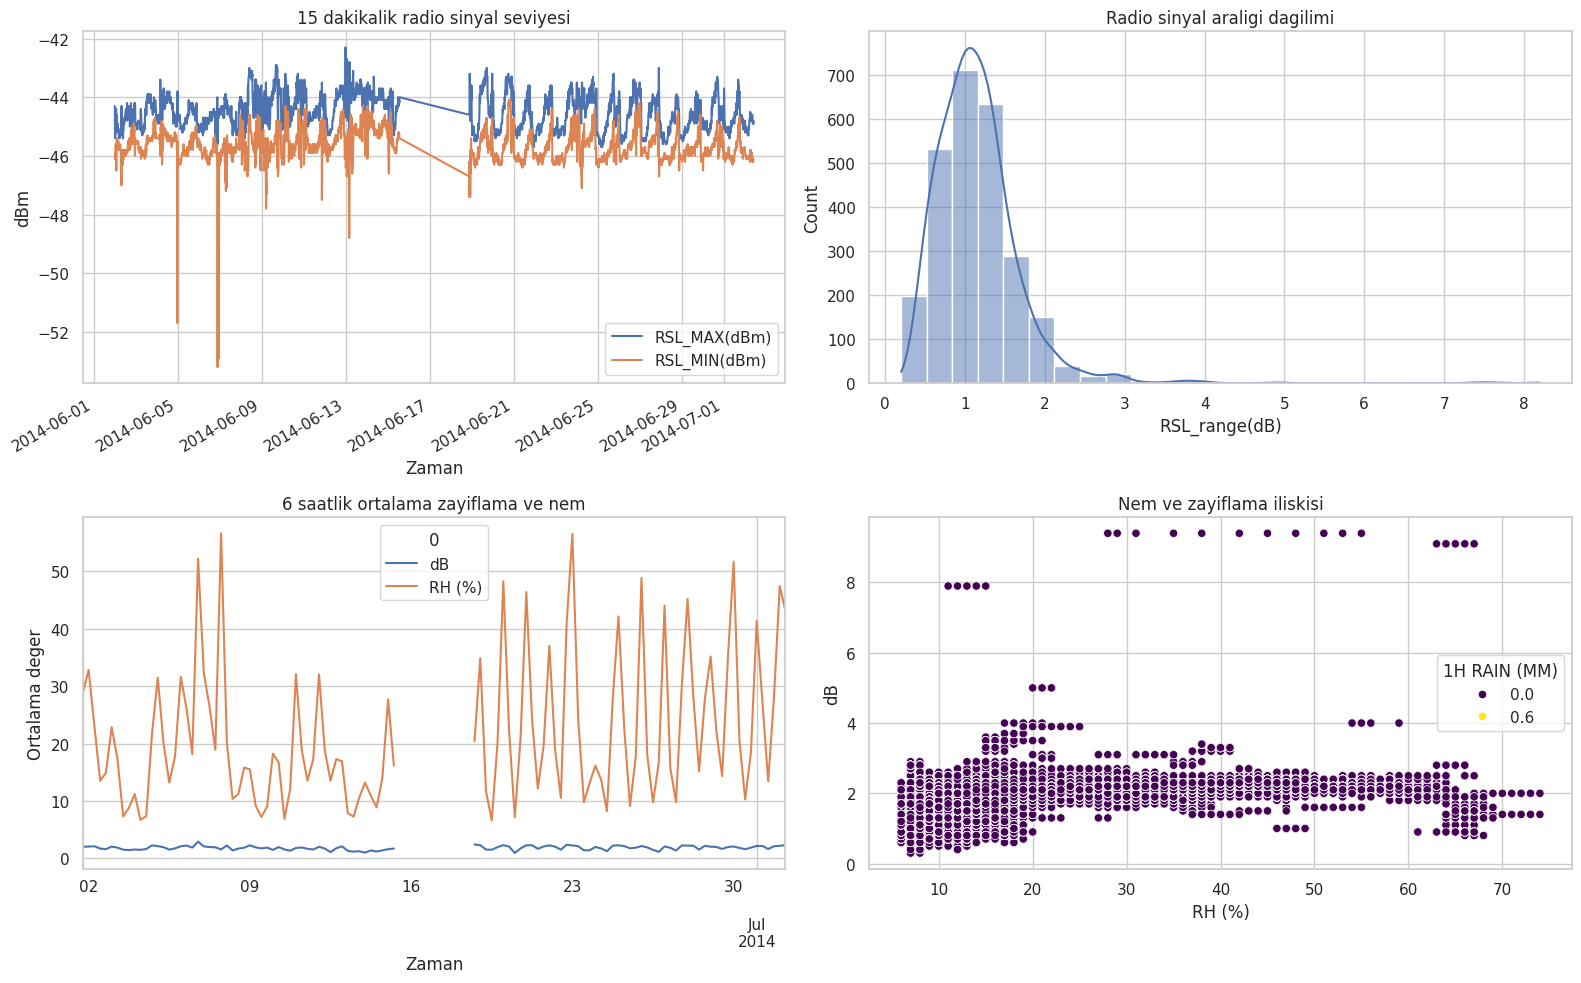

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

radio.plot(
    x='Collection Time',
    y=['RSL_MAX(dBm)', 'RSL_MIN(dBm)'],
    ax=axes[0, 0],
    title='15 dakikalik radio sinyal seviyesi',
)
axes[0, 0].set_xlabel('Zaman')
axes[0, 0].set_ylabel('dBm')

sns.histplot(radio['RSL_range(dB)'].dropna(), bins=25, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Radio sinyal araligi dagilimi')
axes[0, 1].set_xlabel('RSL_range(dB)')

weather_sample = weather.set_index('History file UTC Time')[['dB', '1H RAIN (MM)', 'RH (%)']].resample('6h').mean()
weather_sample[['dB', 'RH (%)']].plot(ax=axes[1, 0], title='6 saatlik ortalama zayiflama ve nem')
axes[1, 0].set_xlabel('Zaman')
axes[1, 0].set_ylabel('Ortalama deger')

rain_scatter = weather[['1H RAIN (MM)', 'dB', 'RH (%)']].dropna()
sns.scatterplot(data=rain_scatter, x='RH (%)', y='dB', hue='1H RAIN (MM)', palette='viridis', ax=axes[1, 1])
axes[1, 1].set_title('Nem ve zayiflama iliskisi')
axes[1, 1].set_xlabel('RH (%)')
axes[1, 1].set_ylabel('dB')

plt.tight_layout()
plt.show()

## 1. Veri Yapısı — `.info()`

In [ ]:
print("=" * 50)
print("RADIO DataFrame .info()")
print("=" * 50)
radio.info()

print("\n")
print("=" * 50)
print("WEATHER DataFrame .info()")
print("=" * 50)
weather.info()